Tampilan cv2_imshow:


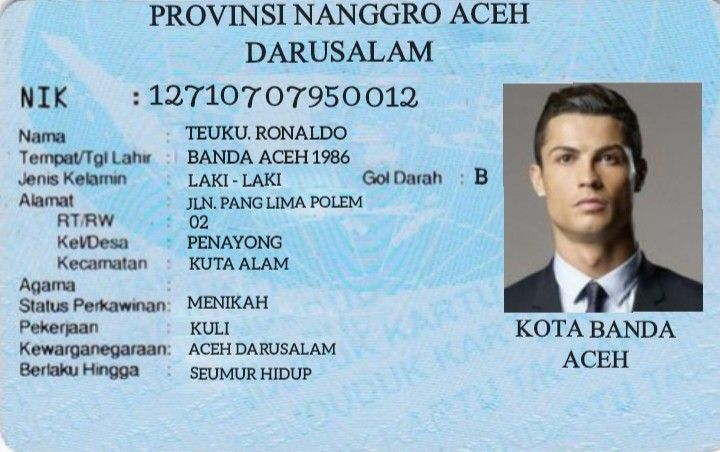


Tampilan plt.imshow:


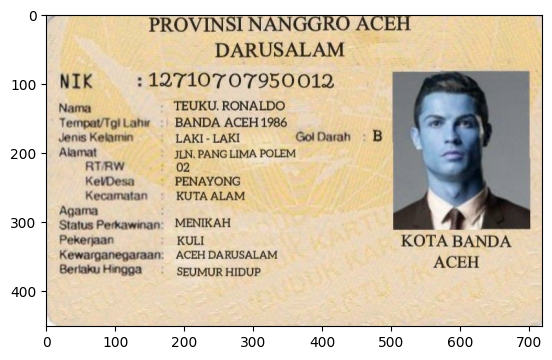

Nilai piksel pada img[100, 100]: [235 215 184]
Kanal B: 235, Kanal G: 215, Kanal R: 184
=== Perbandingan int16 vs int32 ===
int16 -> dtype: int16, min: 0, max: 0, nbytes: 1685400 bytes
int32 -> dtype: int32, min: 0, max: 0, nbytes: 3370800 bytes
Piksel [100, 100] skimage (RGB)        : [184 215 235]
Piksel [100, 100] cv2 BGR->RGB (RGB)   : [184 215 235]
Apakah array bernilai sama persis?: True


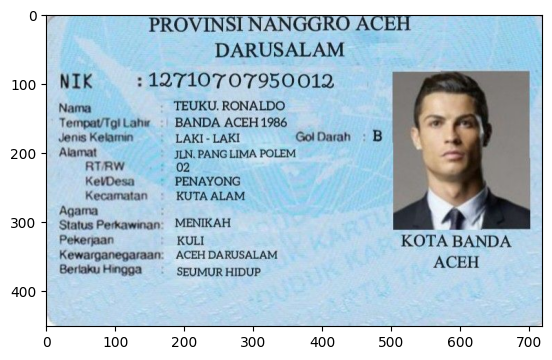

Shape sebelum figsize: (452, 720, 3)


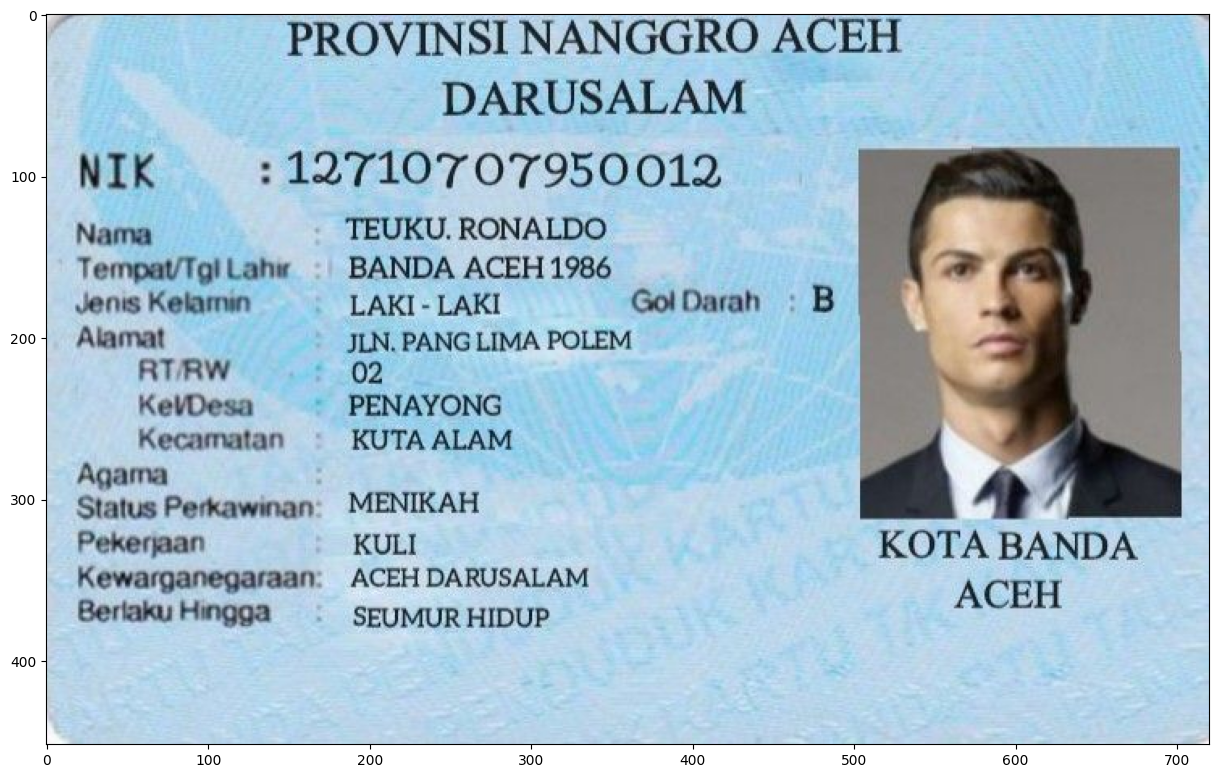

Shape setelah figsize: (452, 720, 3)


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage import io

# NOMOR 1

img = cv.imread('ktp.jpg')

# Tampilan cv2_imshow (asli BGR)
print("Tampilan cv2_imshow:")
cv2_imshow(img)

# Tampilan plt.imshow (tanpa konversi BGR->RGB)
print("\nTampilan plt.imshow:")
plt.imshow(img)
plt.show()

# Bukti Nilai Piksel pada koordinat yang sama (misal baris 100, kolom 100)
pixel_val = img[100, 100] # Urutan array NumPy adalah BGR
print(f"Nilai piksel pada img[100, 100]: {pixel_val}")
print(f"Kanal B: {pixel_val[0]}, Kanal G: {pixel_val[1]}, Kanal R: {pixel_val[2]}")

# NOMOR 2

img_int16 = np.zeros(shape=(530, 530, 3), dtype=np.int16)
img_int32 = np.zeros(shape=(530, 530, 3), dtype=np.int32)

print("=== Perbandingan int16 vs int32 ===")
print(f"int16 -> dtype: {img_int16.dtype}, min: {img_int16.min()}, max: {img_int16.max()}, nbytes: {img_int16.nbytes} bytes")
print(f"int32 -> dtype: {img_int32.dtype}, min: {img_int32.min()}, max: {img_int32.max()}, nbytes: {img_int32.nbytes} bytes")

# NOMOR 4

img_skimage = io.imread('ktp.jpg')
img_cv_bgr = cv.imread('ktp.jpg')
img_cv_rgb = cv.cvtColor(img_cv_bgr, cv.COLOR_BGR2RGB)

print(f"Piksel [100, 100] skimage (RGB)        : {img_skimage[100, 100]}")
print(f"Piksel [100, 100] cv2 BGR->RGB (RGB)   : {img_cv_rgb[100, 100]}")
print("Apakah array bernilai sama persis?:", (img_skimage == img_cv_rgb).all())

# NOMOR 5

plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()
print(f"Shape sebelum figsize: {img.shape}")
plt.figure(figsize=(15, 15))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()
print(f"Shape setelah figsize: {img.shape}") # Nilai shape tetap identik





PERTANYAAN PRAKTIKUM
1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow()
tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan
mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.  
Jawab:  
Fungsi cv2.imread() membaca citra dalam urutan kanal BGR (Blue, Green, Red). Fungsi cv2_imshow() mengasumsikan input berupa format BGR, sehingga menampilkan warna asli. Sebaliknya, plt.imshow() mengasumsikan input berupa format RGB. Akibatnya, pada plt.imshow(), kanal Biru dibaca sebagai Merah dan kanal Merah dibaca sebagai Biru, sehingga warna tampak terbalik (kebiruan/kekuningan).

2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32.
Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya
berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.  
Jawab:
* Perbedaan Tampilan: Tidak ada perbedaan visual, keduanya sama-sama menampilkan bidang hitam pekat karena semua piksel bernilai 0.
* Perbedaan Ukuran Memori: Berbeda. Tipe int16 menggunakan 2 byte (16 bit) per elemen, sedangkan int32 menggunakan 4 byte (32 bit) per elemen. Akibatnya, nbytes dari int32 tepat dua kali lipat dari int16.

3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan
mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?  
Jawab:
* Kegunaan: from google.colab.patches import cv2_imshow berfungsi untuk menampilkan gambar format BGR langsung sebagai output sel di Google Colaboratory.
* Mengapa cv2.imshow() Tidak Bisa Digunakan: cv2.imshow() bawaan OpenCV dirancang untuk membuka jendela GUI (Graphical User Interface) berbasis sistem operasi desktop lokal. Google Colab berjalan di lingkungan remote server/cloud tanpa server X-display (headless), sehingga memanggil cv2.imshow() akan menyebabkan error atau membuat kernel Colab crash.

4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan
dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang
sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang
kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan
visual saja.  
Jawab:
* skimage.io.imread() membaca citra langsung dalam susunan RGB.
* cv2.imread() membaca citra dalam susunan BGR, namun setelah dilakukan cv2.cvtColor(img, cv2.COLOR_BGR2RGB), urutannya diubah menjadi RGB.

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai
img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra
dan mengubah ukuran tampilan.  
jawab:  
Nilai img.shape tidak ikut berubah sama sekali.